# Orientation-bias test — cuboid box

Rotate a cuboidal box on the voxel grid and measure how the Minkowski
functionals and rank-2 tensor anisotropy indices vary with orientation.
Compare every measured quantity against its exact analytical reference to
quantify the orientation bias introduced by voxel discretisation.

**Shape**: cuboidal box AX × AY × AZ (default 20 × 12 × 8)

**Rotation protocols**
- **Plane Z**: sweep around z-axis, 0°–175° in 5° steps
- **Plane X**: sweep around x-axis, 0°–175° in 5° steps
- **Random**: N_RANDOM Haar-uniform SO(3) rotations

**Quantities**
- Scalars: w000, w100, w200, w300
- Rank-2 anisotropy index β = λ_min / λ_max for all six tensors

All figures show the exact analytical value as a dashed reference line.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import platform
from scipy.spatial.transform import Rotation as Rot
import pykarambola

print(f'pykarambola : {pykarambola.__version__}')
print(f'Python      : {platform.python_version()}')
print(f'OS          : {platform.system()} {platform.release()}')

pykarambola : 0.5.0
Python      : 3.11.13
OS          : Darwin 24.6.0


In [2]:
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Box full dimensions
AX, AY, AZ = 20.0, 12.0, 8.0

# Resolution sweep  (AX / n  →  voxel size)
PROBE_DENOMS = [20, 40, 60]
PROBE_VOXELS = [AX / n for n in PROBE_DENOMS]

# Rotation sweep parameters
PLANE_STEP_DEG = 5
PLANE_ANGLES   = np.arange(0, 180, PLANE_STEP_DEG)   # 0°, 5°, ..., 175°
N_RANDOM       = 200
RANDOM_SEED    = 42

RANK2   = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
SCALARS = ['w000', 'w100', 'w200', 'w300']

print(f'Box          : AX={AX}, AY={AY}, AZ={AZ}')
print(f'Resolutions  : {" | ".join([f"AX/{n} = {AX/n:.3f}" for n in PROBE_DENOMS])}')
print(f'Plane sweep  : {len(PLANE_ANGLES)} angles, 0°–{PLANE_ANGLES[-1]:.0f}°, step {PLANE_STEP_DEG}°')
print(f'Random rots  : {N_RANDOM}')
print(f'Total runs   : {len(PROBE_DENOMS) * (2*len(PLANE_ANGLES) + N_RANDOM)}')

Box          : AX=20.0, AY=12.0, AZ=8.0
Resolutions  : AX/20 = 1.000 | AX/40 = 0.500 | AX/60 = 0.333
Plane sweep  : 36 angles, 0°–175°, step 5°
Random rots  : 200
Total runs   : 816


In [3]:
# ── Exact analytical references — cuboid (Schröder-Turk et al., Appendix A) ──

def box_refs(ax, ay, az):
    """Exact analytical references for a cuboid centred at origin with full dimensions ax×ay×az.
    Returns scalars, tensor eigenvalues (sorted ascending), and β = ev[0]/ev[2].
    Derived quantities (trace, relative errors) are computed in figure cells.
    """
    w000 = ax * ay * az
    w100 = 2*(ax*ay + ay*az + az*ax) / 3
    w200 = np.pi*(ax + ay + az) / 3
    w300 = 4*np.pi / 3

    tensor_diags = {
        'w020': [ax**3*ay*az/12,                      ay**3*ax*az/12,                      az**3*ax*ay/12],
        'w120': [ax**3*(ay+az)/18 + ax**2*ay*az/6,   ay**3*(ax+az)/18 + ay**2*ax*az/6,   az**3*(ax+ay)/18 + az**2*ax*ay/6],
        'w220': [np.pi/36*(ax**3 + 3*ax**2*(ay+az)), np.pi/36*(ay**3 + 3*ay**2*(ax+az)), np.pi/36*(az**3 + 3*az**2*(ax+ay))],
        'w320': [np.pi/3*ax**2,                       np.pi/3*ay**2,                       np.pi/3*az**2],
        'w102': [2*ay*az/3,                           2*ax*az/3,                           2*ax*ay/3],
        'w202': [np.pi/6*(ay+az),                     np.pi/6*(ax+az),                     np.pi/6*(ax+ay)],
    }

    out = {'w000': w000, 'w100': w100, 'w200': w200, 'w300': w300}
    for name, diags in tensor_diags.items():
        ev = sorted(diags)
        out[f'{name}_ev0']  = ev[0]
        out[f'{name}_ev1']  = ev[1]
        out[f'{name}_ev2']  = ev[2]
        out[f'{name}_beta'] = ev[0] / ev[2]
    return out

BOX_REF = box_refs(AX, AY, AZ)
print('Box exact analytical references:')
for k, v in BOX_REF.items():
    print(f'  {k:<16} {v:.6f}')

Box exact analytical references:
  w000             1920.000000
  w100             330.666667
  w200             41.887902
  w300             4.188790
  w020_ev0         10240.000000
  w020_ev1         23040.000000
  w020_ev2         64000.000000
  w020_beta        0.160000
  w120_ev0         3470.222222
  w120_ev1         6528.000000
  w120_ev2         15288.888889
  w120_beta        0.226977
  w220_ev0         580.845575
  w220_ev1         1206.371579
  w220_ev2         2792.526803
  w220_beta        0.208000
  w320_ev0         67.020643
  w320_ev1         150.796447
  w320_ev2         418.879020
  w320_beta        0.160000
  w102_ev0         64.000000
  w102_ev1         106.666667
  w102_ev2         160.000000
  w102_beta        0.400000
  w202_ev0         10.471976
  w202_ev1         14.660766
  w202_ev2         16.755161
  w202_beta        0.625000


In [4]:
# ── Mask generation ───────────────────────────────────────────────────────────

def make_box_mask(ax, ay, az, R, voxel_size, pad=4):
    """Binary mask for a box with full dimensions ax×ay×az rotated by R (3×3).

    R maps box-frame axes to lab-frame axes (R @ p_box = p_lab).
    A lab-frame voxel centre x is inside the box iff R^T @ x is within the
    half-dimensions. In numpy row-vector convention: pts @ R applies R^T to each row.
    """
    r_bound = 0.5 * np.sqrt(ax**2 + ay**2 + az**2)
    n_half  = int(np.ceil(r_bound / voxel_size)) + pad

    c = np.arange(-n_half, n_half + 1, dtype=np.float64) * voxel_size
    X0, X1, X2 = np.meshgrid(c, c, c, indexing='ij')
    pts = np.stack([X0.ravel(), X1.ravel(), X2.ravel()], axis=-1)
    pts_box = pts @ R

    inside = (
        (np.abs(pts_box[:, 0]) <= ax / 2) &
        (np.abs(pts_box[:, 1]) <= ay / 2) &
        (np.abs(pts_box[:, 2]) <= az / 2)
    )
    return inside.reshape(X0.shape).astype(np.uint8)


def measure(mask, voxel_size):
    """Run pykarambola, return raw scalars and raw eigenvalues per tensor.
    Derived quantities (trace, beta, relative errors) are computed in figure cells.
    """
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = pykarambola.minkowski_tensors_from_label_image(
            mask, spacing=(voxel_size, voxel_size, voxel_size)
        )[1]
    out = {}
    for sc in SCALARS:
        out[sc] = float(r.get(sc, np.nan))
    for name in RANK2:
        ev = r.get(f'{name}_eigvals')
        if ev is not None:
            out[f'{name}_ev0'] = float(ev[0])   # λ_min
            out[f'{name}_ev1'] = float(ev[1])   # λ_mid
            out[f'{name}_ev2'] = float(ev[2])   # λ_max
        else:
            out[f'{name}_ev0'] = out[f'{name}_ev1'] = out[f'{name}_ev2'] = np.nan
    return out


print('Functions defined.')

Functions defined.


In [5]:
# ── Rotation generation ───────────────────────────────────────────────────────

# Plane sweeps: list of (angle_deg, rotation_matrix)
ROTS_PLANE_Z = [(deg, Rot.from_euler('z', deg, degrees=True).as_matrix())
                for deg in PLANE_ANGLES]

ROTS_PLANE_X = [(deg, Rot.from_euler('x', deg, degrees=True).as_matrix())
                for deg in PLANE_ANGLES]

# Haar-uniform random rotations: list of (index, rotation_matrix)
ROTS_RANDOM  = [(i, r.as_matrix())
                for i, r in enumerate(Rot.random(N_RANDOM, random_state=RANDOM_SEED))]

print(f'Plane-Z : {len(ROTS_PLANE_Z)} rotations  (0°–{PLANE_ANGLES[-1]:.0f}°, step {PLANE_STEP_DEG}°)')
print(f'Plane-X : {len(ROTS_PLANE_X)} rotations  (0°–{PLANE_ANGLES[-1]:.0f}°, step {PLANE_STEP_DEG}°)')
print(f'Random  : {len(ROTS_RANDOM)} rotations  (Haar-uniform, seed={RANDOM_SEED})')

Plane-Z : 36 rotations  (0°–175°, step 5°)
Plane-X : 36 rotations  (0°–175°, step 5°)
Random  : 200 rotations  (Haar-uniform, seed=42)


In [6]:
# ── Orientation + resolution sweep ───────────────────────────────────────────

def run_protocol(protocol_name, rots, vox, n):
    rows = []
    for key, R in rots:
        mask = make_box_mask(AX, AY, AZ, R, vox)
        row  = measure(mask, vox)
        row.update({'protocol': protocol_name, 'n': n, 'voxel_size': vox, 'key': key})
        rows.append(row)
    return rows

all_rows = []
for n, vox in zip(PROBE_DENOMS, PROBE_VOXELS):
    print(f'AX/{n}  (voxel = {vox:.3f}) ...')
    all_rows += run_protocol('plane_z', ROTS_PLANE_Z, vox, n)
    all_rows += run_protocol('plane_x', ROTS_PLANE_X, vox, n)
    all_rows += run_protocol('random',  ROTS_RANDOM,  vox, n)
    print(f'  done.')

DF = pd.DataFrame(all_rows)
print(f'\nTotal rows: {len(DF)}')
print(DF.groupby(['protocol', 'n']).size().to_string())

AX/20  (voxel = 1.000) ...
  done.
AX/40  (voxel = 0.500) ...
  done.
AX/60  (voxel = 0.333) ...
  done.

Total rows: 816
protocol  n 
plane_x   20     36
          40     36
          60     36
plane_z   20     36
          40     36
          60     36
random    20    200
          40    200
          60    200


In [7]:
# ── Derived columns — computed once from raw eigenvalues, no re-run needed ────
# Add beta, trace, and analytical trace to DF and BOX_REF.
# Re-run only this cell (and below) whenever a new derived quantity is needed.

for _n in RANK2:
    DF[f'{_n}_beta']  = DF[f'{_n}_ev0'] / DF[f'{_n}_ev2']
    DF[f'{_n}_trace'] = DF[f'{_n}_ev0'] + DF[f'{_n}_ev1'] + DF[f'{_n}_ev2']
    BOX_REF[f'{_n}_trace'] = BOX_REF[f'{_n}_ev0'] + BOX_REF[f'{_n}_ev1'] + BOX_REF[f'{_n}_ev2']

print('Derived columns added to DF:', [c for c in DF.columns if '_beta' in c or '_trace' in c])

Derived columns added to DF: ['w020_beta', 'w020_trace', 'w120_beta', 'w120_trace', 'w220_beta', 'w220_trace', 'w320_beta', 'w320_trace', 'w102_beta', 'w102_trace', 'w202_beta', 'w202_trace']


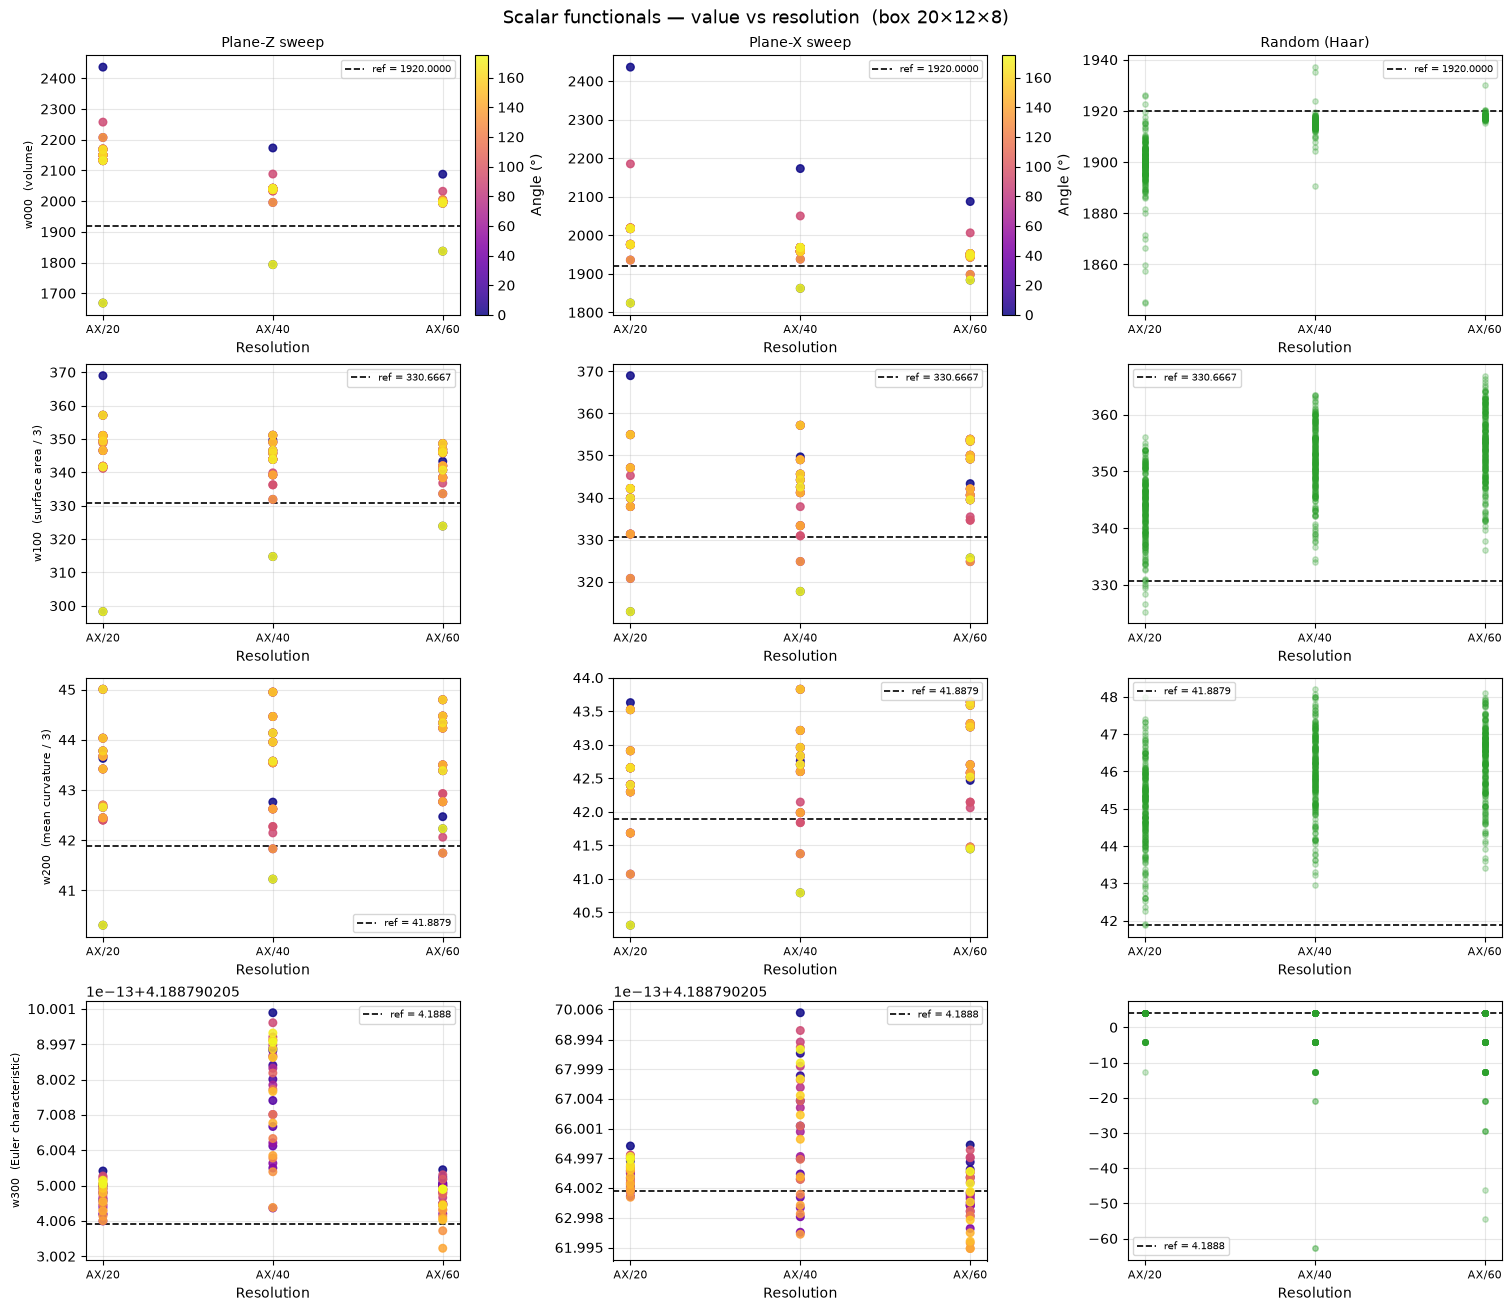

In [8]:
# ── Figure: scalar values vs resolution, colored by angle ────────────────────
SCALAR_LABELS = {
    'w000': 'w000  (volume)',
    'w100': 'w100  (surface area / 3)',
    'w200': 'w200  (mean curvature / 3)',
    'w300': 'w300  (Euler characteristic)',
}
PROT_LABELS = {'plane_z': 'Plane-Z sweep', 'plane_x': 'Plane-X sweep', 'random': 'Random (Haar)'}
PROTOCOLS   = ['plane_z', 'plane_x', 'random']
norm_angle  = Normalize(vmin=0, vmax=175)

fig, axes = plt.subplots(4, 3, figsize=(15, 13), constrained_layout=True)
fig.suptitle(f'Scalar functionals — value vs resolution  '
             f'(box {AX:.0f}×{AY:.0f}×{AZ:.0f})', fontsize=13)

for row, sc in enumerate(SCALARS):
    ref = BOX_REF[sc]
    for col, proto in enumerate(PROTOCOLS):
        ax   = axes[row, col]
        sub  = DF[DF['protocol'] == proto]
        if proto in ('plane_z', 'plane_x'):
            sp = ax.scatter(sub['n'], sub[sc], c=sub['key'], cmap='plasma',
                            norm=norm_angle, s=30, alpha=0.85, zorder=3)
            if row == 0:
                fig.colorbar(sp, ax=ax, label='Angle (°)', fraction=0.046, pad=0.04)
        else:
            ax.scatter(sub['n'], sub[sc], color='#2ca02c', s=15, alpha=0.25, zorder=3)
        ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
        ax.set_xticks(PROBE_DENOMS)
        ax.set_xticklabels([f'AX/{n}' for n in PROBE_DENOMS], fontsize=8)
        ax.set_xlabel('Resolution')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(SCALAR_LABELS[sc], fontsize=8)
        if row == 0:
            ax.set_title(PROT_LABELS[proto], fontsize=10)

plt.savefig(os.path.join(RESULTS_DIR, 'probe_scalars_vs_res.pdf'), bbox_inches='tight')
plt.show()

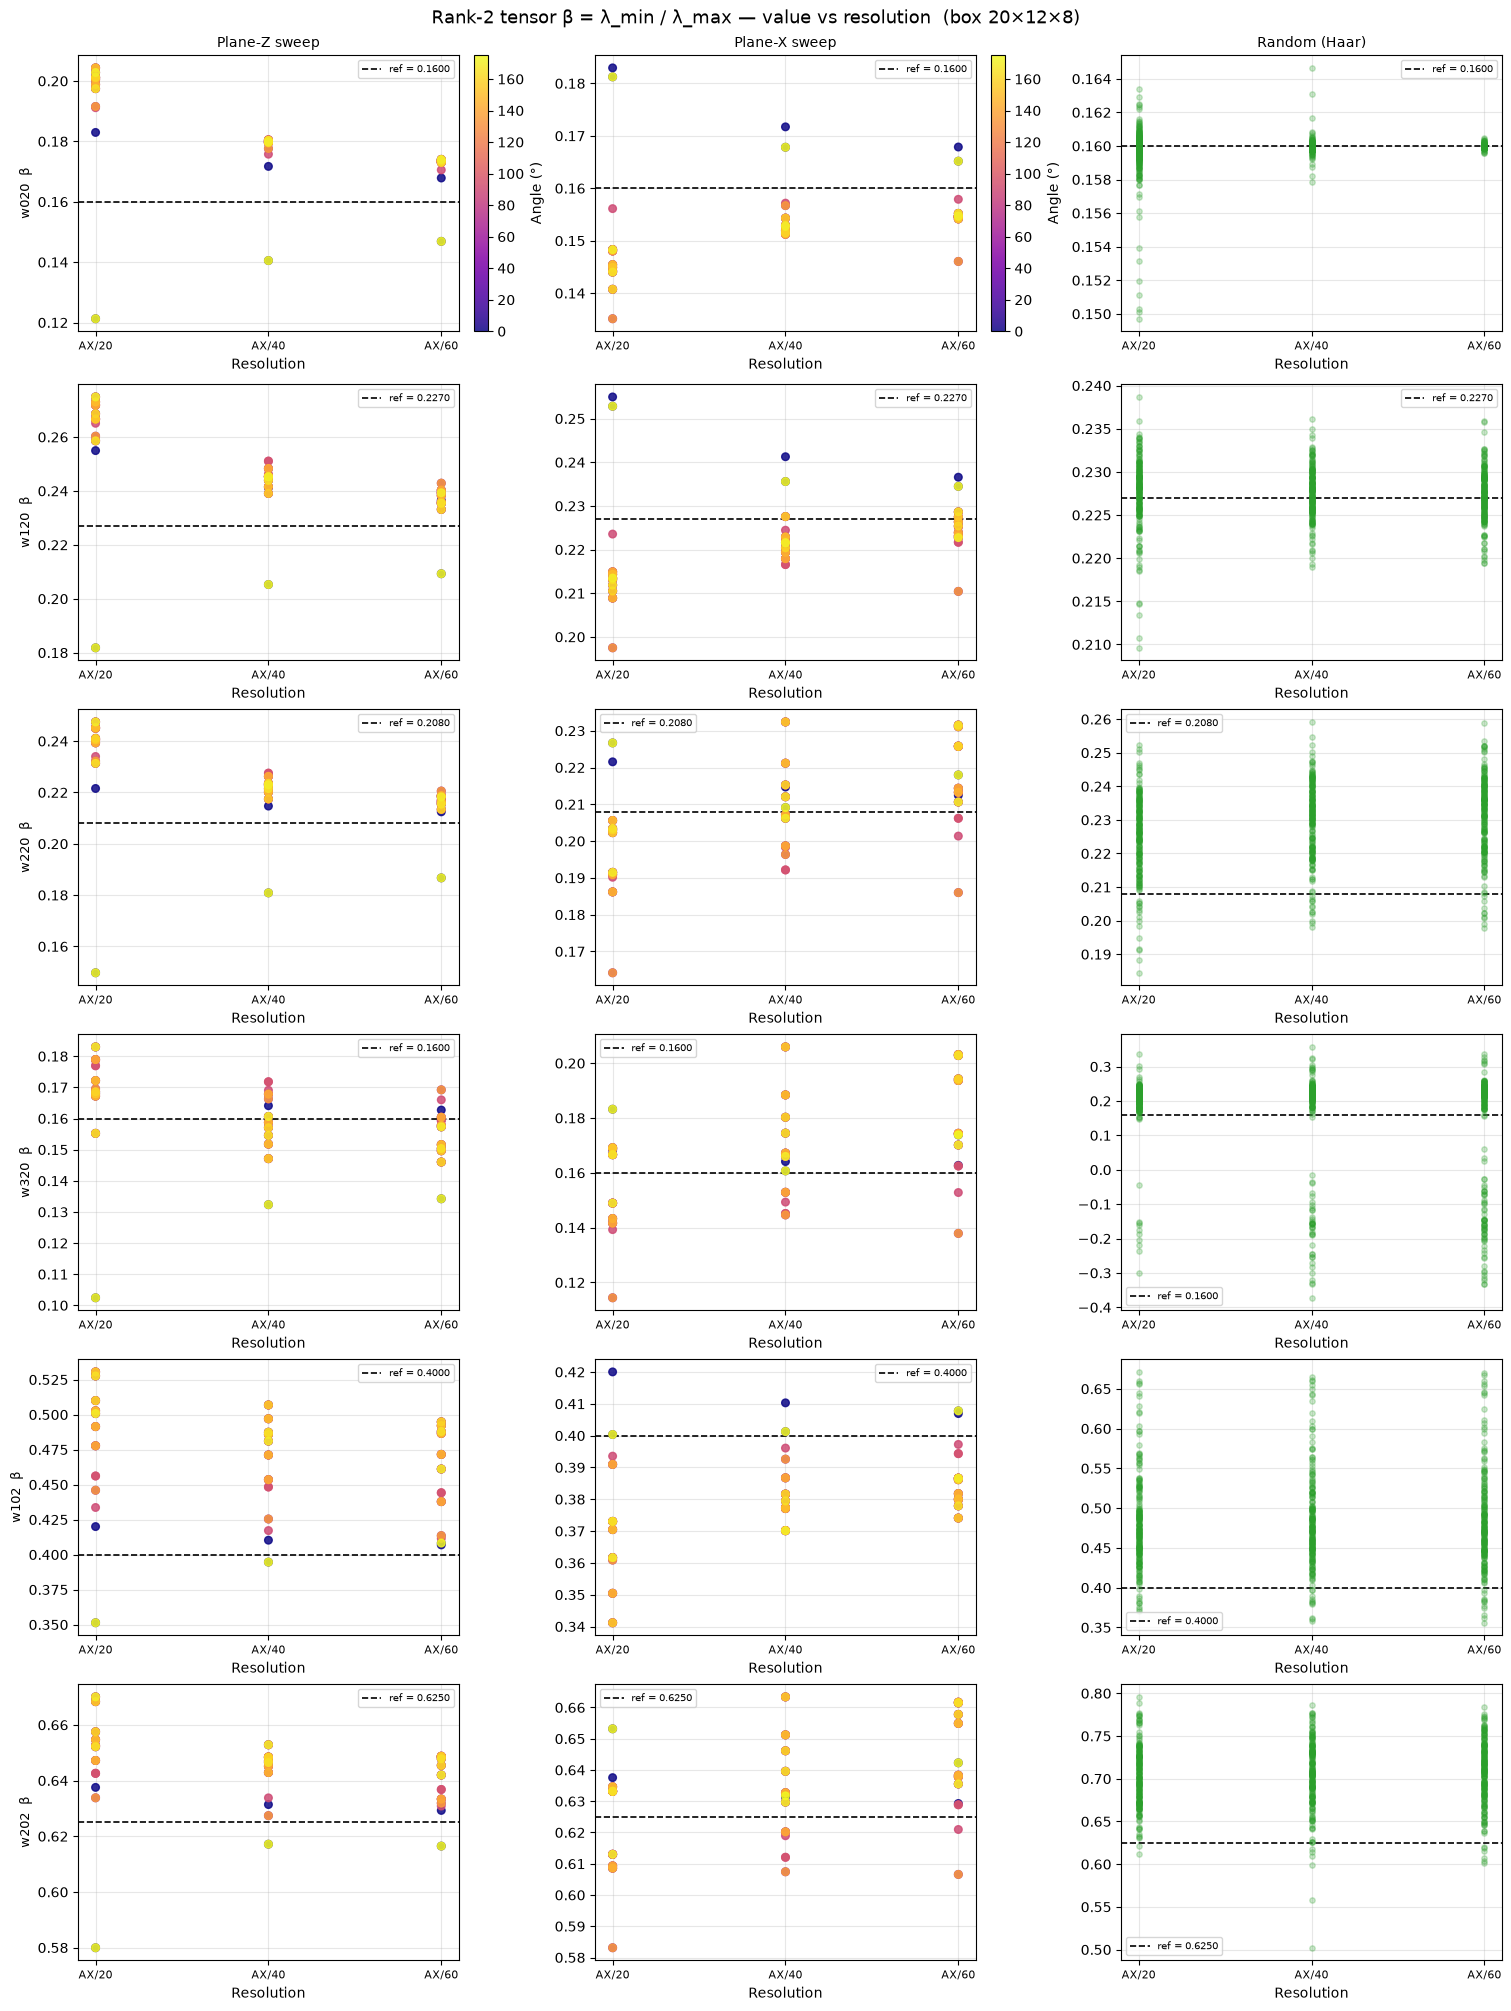

In [9]:
# ── Figure: β vs resolution, colored by angle ────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(15, 20), constrained_layout=True)
fig.suptitle(f'Rank-2 tensor β = λ_min / λ_max — value vs resolution  '
             f'(box {AX:.0f}×{AY:.0f}×{AZ:.0f})', fontsize=13)

for row, name in enumerate(RANK2):
    key_col = f'{name}_beta'
    ref     = BOX_REF[key_col]
    for col, proto in enumerate(PROTOCOLS):
        ax  = axes[row, col]
        sub = DF[DF['protocol'] == proto]
        if proto in ('plane_z', 'plane_x'):
            sp = ax.scatter(sub['n'], sub[key_col], c=sub['key'], cmap='plasma',
                            norm=norm_angle, s=30, alpha=0.85, zorder=3)
            if row == 0:
                fig.colorbar(sp, ax=ax, label='Angle (°)', fraction=0.046, pad=0.04)
        else:
            ax.scatter(sub['n'], sub[key_col], color='#2ca02c', s=15, alpha=0.25, zorder=3)
        ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
        ax.set_xticks(PROBE_DENOMS)
        ax.set_xticklabels([f'AX/{n}' for n in PROBE_DENOMS], fontsize=8)
        ax.set_xlabel('Resolution')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(f'{name}  β', fontsize=9)
        if row == 0:
            ax.set_title(PROT_LABELS[proto], fontsize=10)

plt.savefig(os.path.join(RESULTS_DIR, 'probe_beta_vs_res.pdf'), bbox_inches='tight')
plt.show()

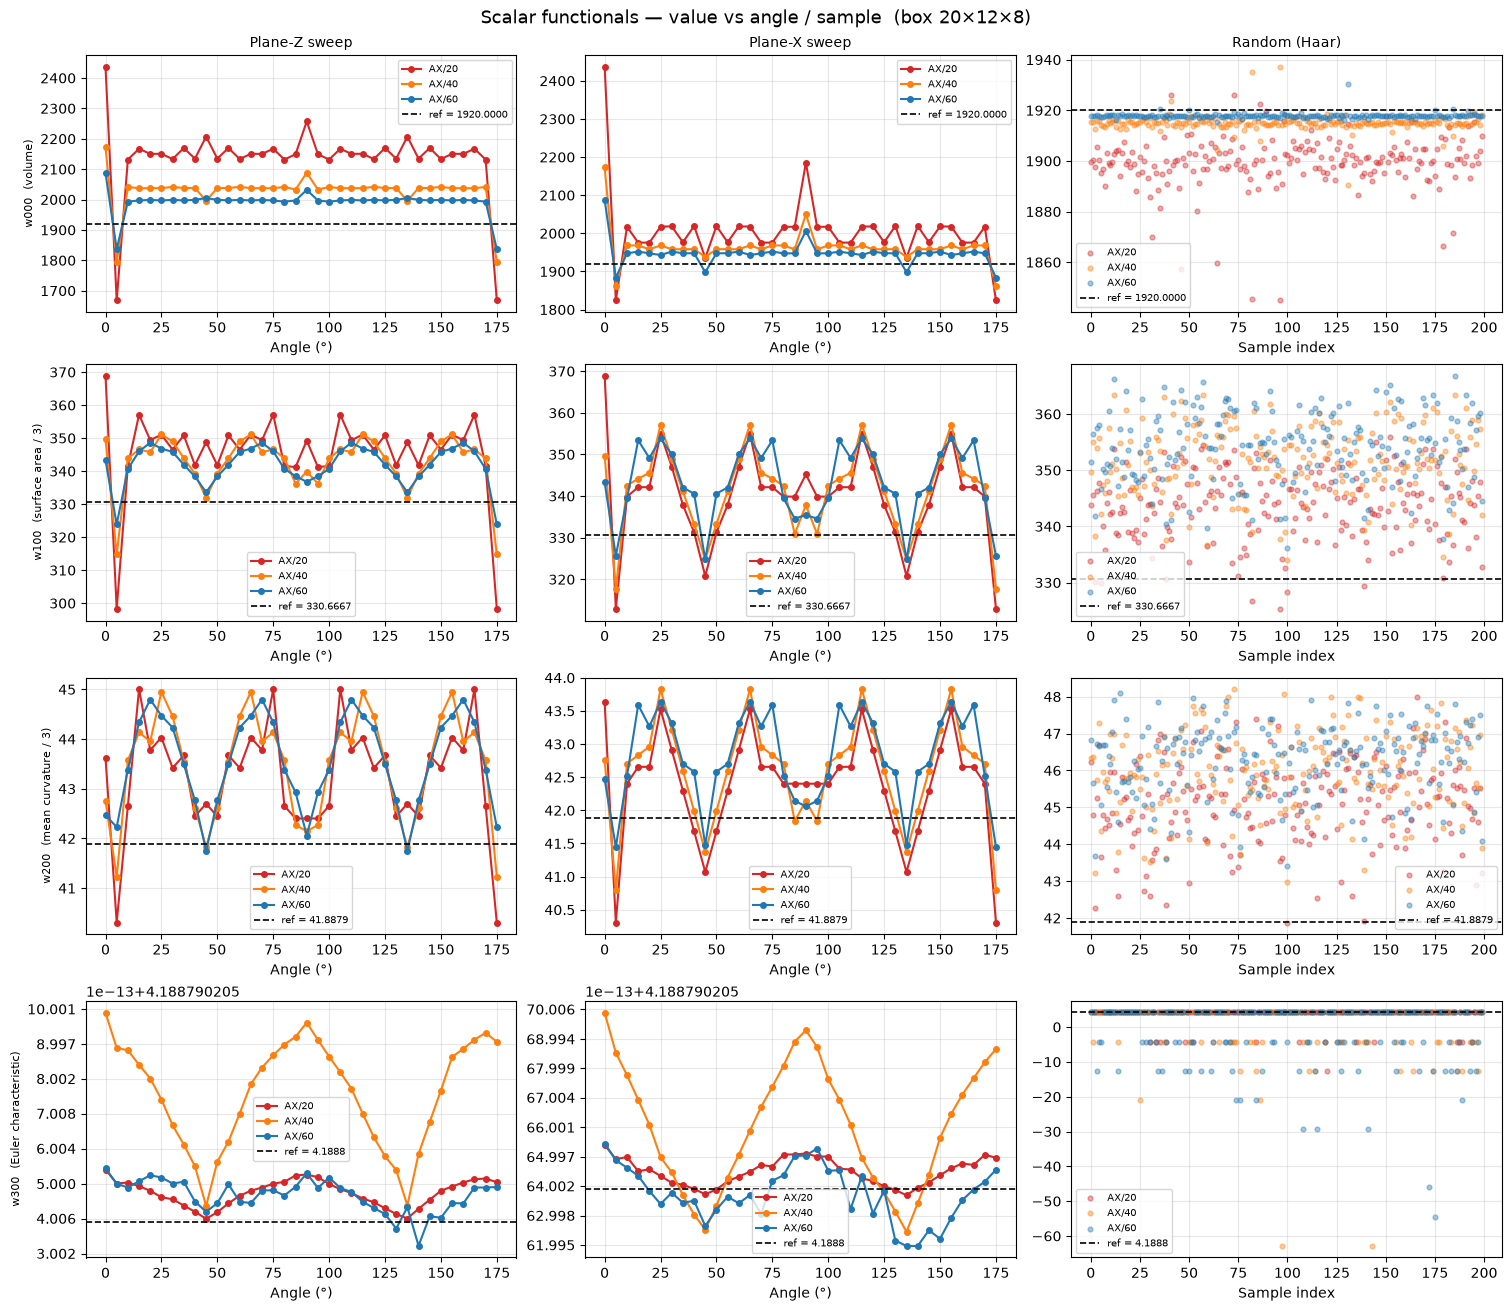

In [10]:
# ── Figure: scalar values vs angle — one curve per resolution ────────────────
RES_COLORS = ['#d62728', '#ff7f0e', '#1f77b4']   # coarse → fine

fig, axes = plt.subplots(4, 3, figsize=(15, 13), constrained_layout=True)
fig.suptitle(f'Scalar functionals — value vs angle / sample  '
             f'(box {AX:.0f}×{AY:.0f}×{AZ:.0f})', fontsize=13)

for row, sc in enumerate(SCALARS):
    ref = BOX_REF[sc]

    for col, proto in enumerate(['plane_z', 'plane_x']):
        ax = axes[row, col]
        for n, color in zip(PROBE_DENOMS, RES_COLORS):
            sub = DF[(DF['protocol'] == proto) & (DF['n'] == n)].sort_values('key')
            ax.plot(sub['key'], sub[sc], 'o-', color=color, lw=1.5, ms=4, label=f'AX/{n}')
        ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
        ax.set_xlabel('Angle (°)')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(SCALAR_LABELS[sc], fontsize=8)
        if row == 0:
            ax.set_title(PROT_LABELS[proto], fontsize=10)

    # Random: scatter, one colour per resolution
    ax = axes[row, 2]
    for n, color in zip(PROBE_DENOMS, RES_COLORS):
        sub = DF[(DF['protocol'] == 'random') & (DF['n'] == n)].reset_index(drop=True)
        ax.scatter(sub.index, sub[sc], color=color, s=12, alpha=0.4, label=f'AX/{n}')
    ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
    ax.set_xlabel('Sample index')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title(PROT_LABELS['random'], fontsize=10)

plt.savefig(os.path.join(RESULTS_DIR, 'probe_scalars_vs_angle.pdf'), bbox_inches='tight')
plt.show()

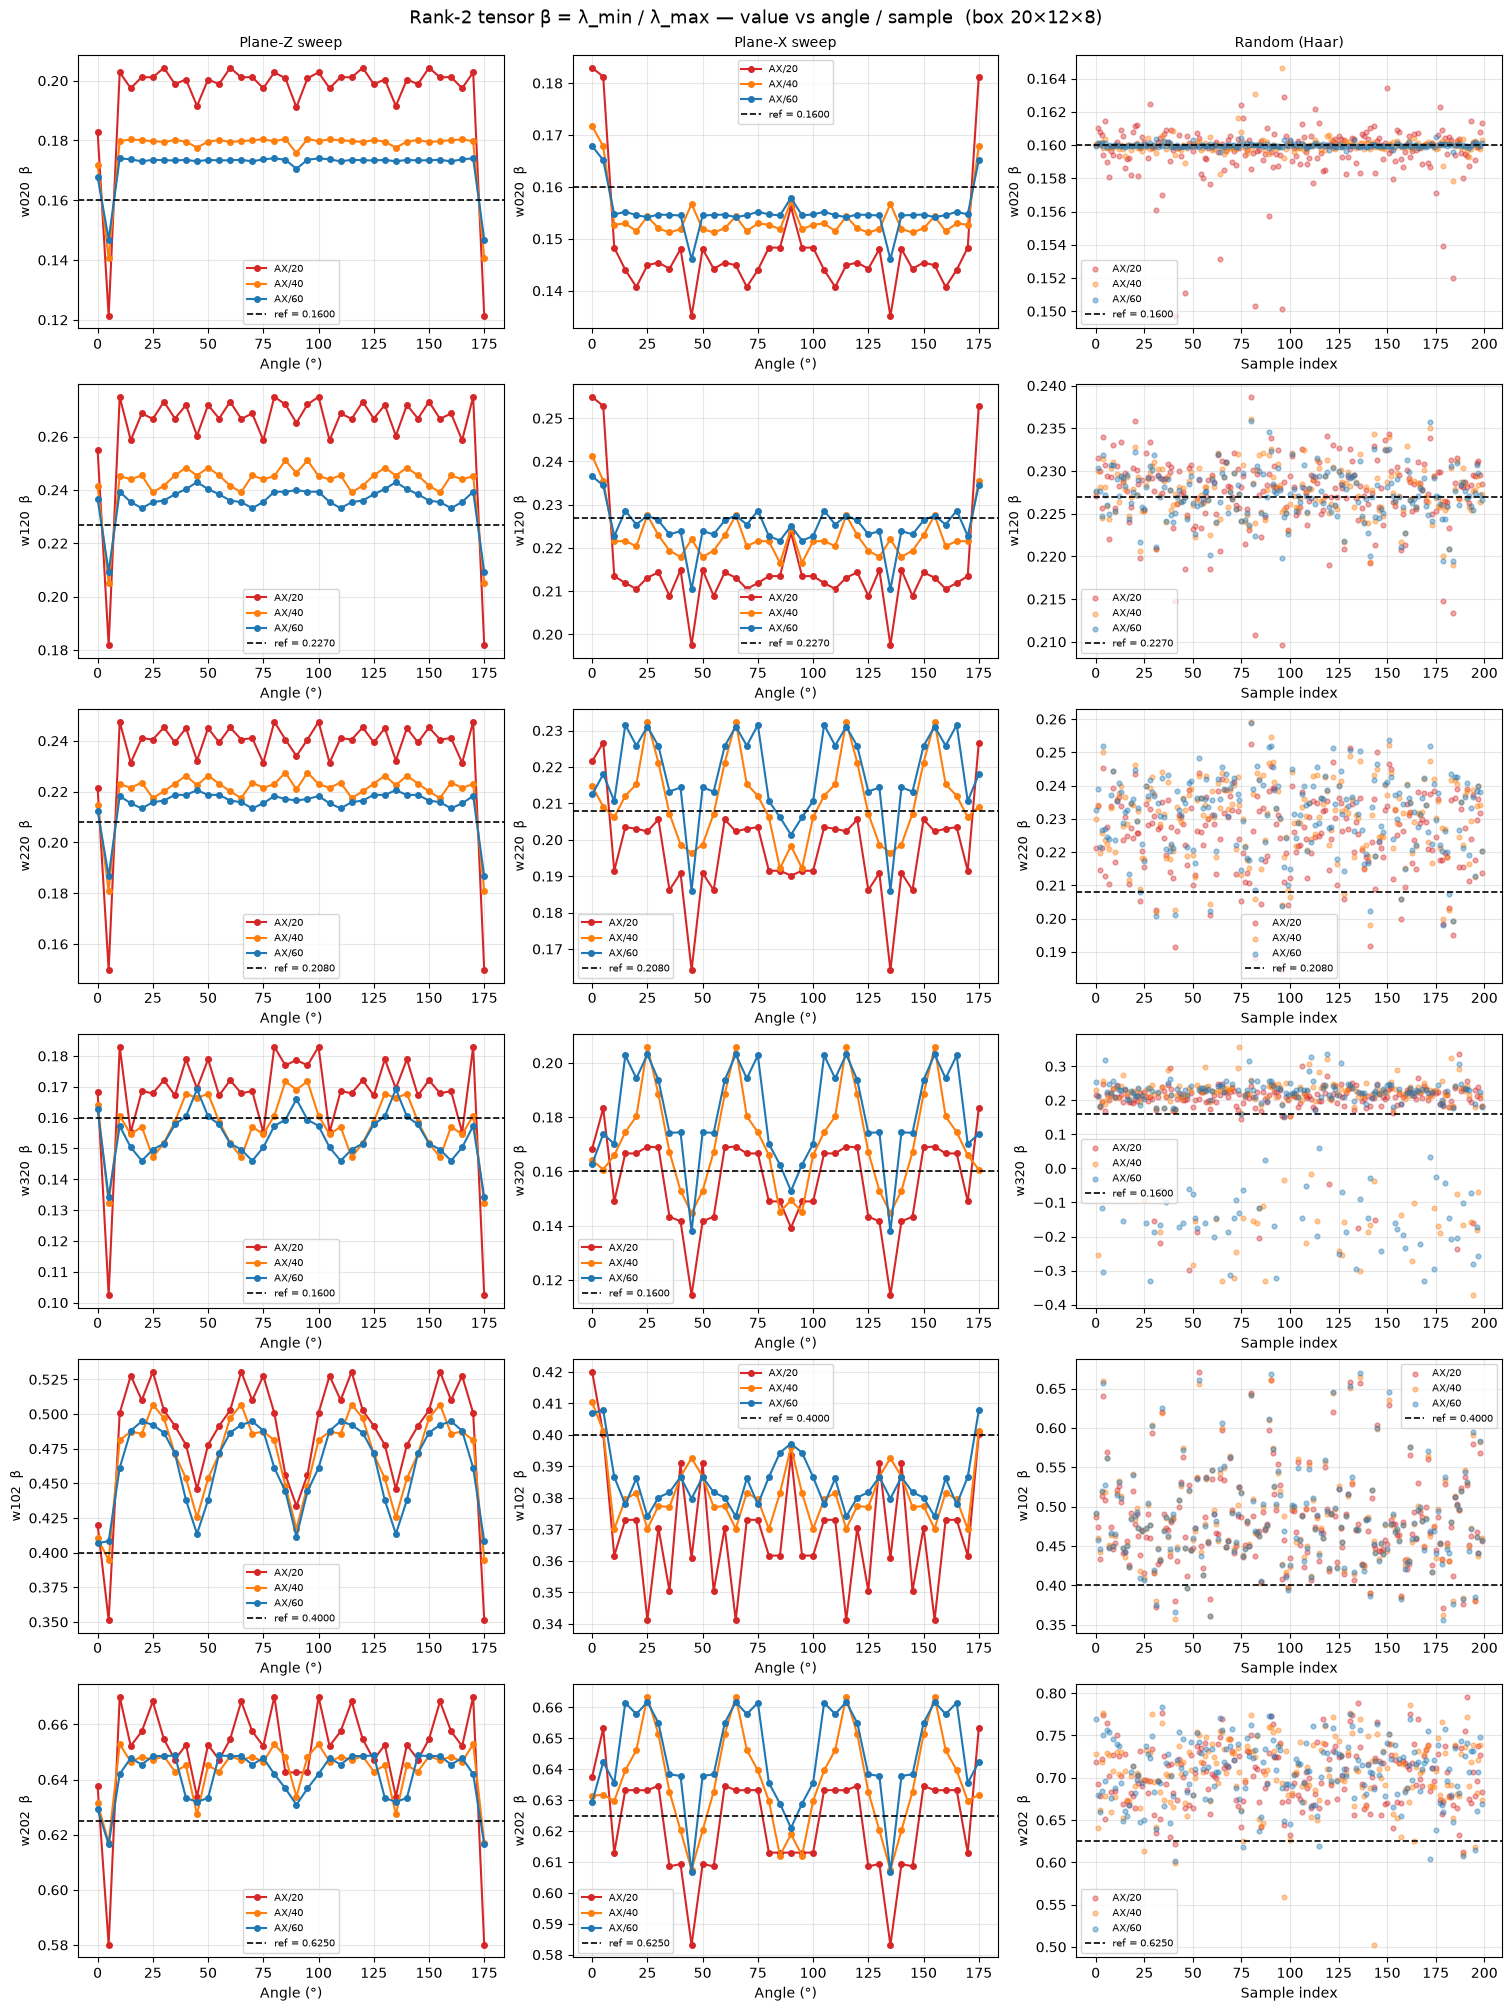

In [11]:
# ── Figure: β vs angle — one curve per resolution ────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(15, 20), constrained_layout=True)
fig.suptitle(f'Rank-2 tensor β = λ_min / λ_max — value vs angle / sample  '
             f'(box {AX:.0f}×{AY:.0f}×{AZ:.0f})', fontsize=13)

for row, name in enumerate(RANK2):
    key_col = f'{name}_beta'
    ref     = BOX_REF[key_col]

    for col, proto in enumerate(['plane_z', 'plane_x']):
        ax = axes[row, col]
        for n, color in zip(PROBE_DENOMS, RES_COLORS):
            sub = DF[(DF['protocol'] == proto) & (DF['n'] == n)].sort_values('key')
            ax.plot(sub['key'], sub[key_col], 'o-', color=color, lw=1.5, ms=4, label=f'AX/{n}')
        ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
        ax.set_xlabel('Angle (°)')
        ax.set_ylabel(f'{name}  β', fontsize=9)
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(PROT_LABELS[proto], fontsize=10)

    # Random: scatter, one colour per resolution
    ax = axes[row, 2]
    for n, color in zip(PROBE_DENOMS, RES_COLORS):
        sub = DF[(DF['protocol'] == 'random') & (DF['n'] == n)].reset_index(drop=True)
        ax.scatter(sub.index, sub[key_col], color=color, s=12, alpha=0.4, label=f'AX/{n}')
    ax.axhline(ref, color='k', ls='--', lw=1.2, label=f'ref = {ref:.4f}')
    ax.set_xlabel('Sample index')
    ax.set_ylabel(f'{name}  β', fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title(PROT_LABELS['random'], fontsize=10)

plt.savefig(os.path.join(RESULTS_DIR, 'probe_beta_vs_angle.pdf'), bbox_inches='tight')
plt.show()

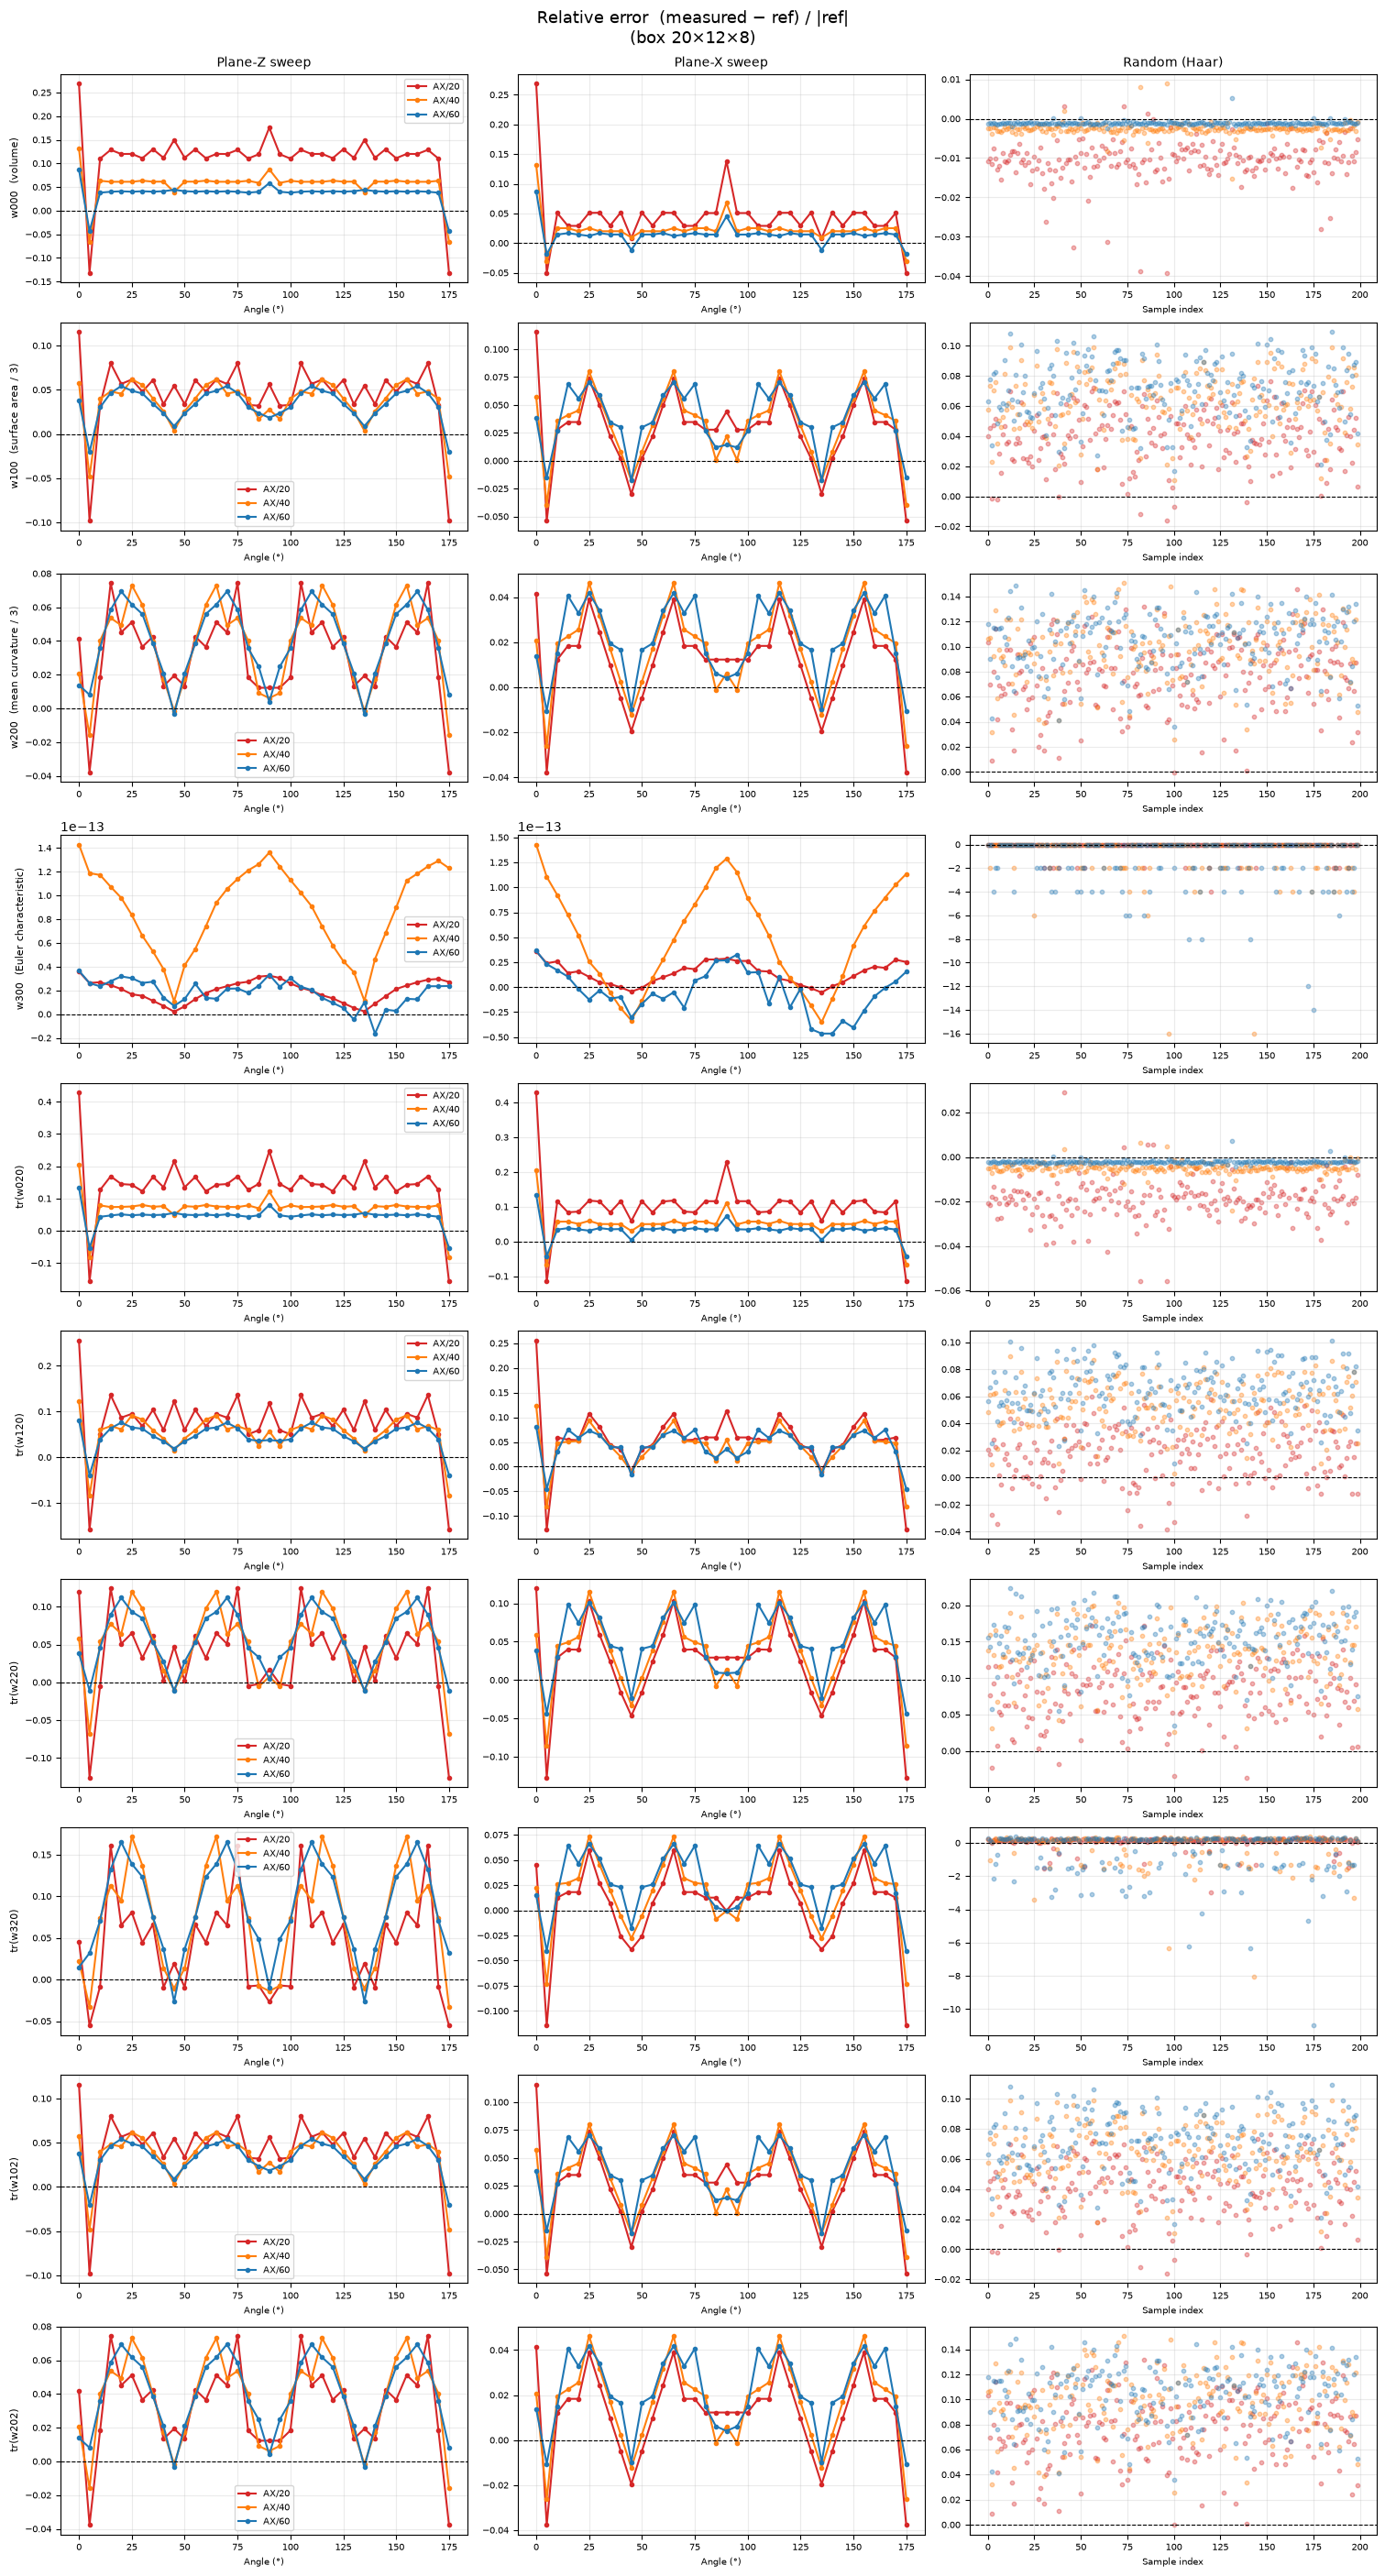

In [12]:
# ── Figure: relative error (measured − ref) / |ref| ──────────────────────────
# Rows 0–3 : scalar functionals
# Rows 4–9 : tensor trace = ev0 + ev1 + ev2

def rel_err(series, ref):
    return (series - ref) / abs(ref)

TRACE_LABELS = {f'{n}_trace': f'tr({n})' for n in RANK2}
ROW_KEYS   = SCALARS + [f'{n}_trace' for n in RANK2]
ROW_LABELS = {**SCALAR_LABELS, **TRACE_LABELS}

fig, axes = plt.subplots(10, 3, figsize=(15, 28), constrained_layout=True)
fig.suptitle(f'Relative error  (measured − ref) / |ref|\n'
             f'(box {AX:.0f}×{AY:.0f}×{AZ:.0f})', fontsize=13)

for row, qty in enumerate(ROW_KEYS):
    ref = BOX_REF[qty]
    for col, proto in enumerate(PROTOCOLS):
        ax      = axes[row, col]
        sub_all = DF[DF['protocol'] == proto]

        for n, color in zip(PROBE_DENOMS, RES_COLORS):
            sub = sub_all[sub_all['n'] == n]
            if proto != 'random':
                sub = sub.sort_values('key')
                ax.plot(sub['key'], rel_err(sub[qty], ref),
                        'o-', color=color, lw=1.5, ms=3, label=f'AX/{n}')
            else:
                sub = sub.reset_index(drop=True)
                ax.scatter(sub.index, rel_err(sub[qty], ref),
                           color=color, s=10, alpha=0.35, label=f'AX/{n}')

        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.set_xlabel('Angle (°)' if proto != 'random' else 'Sample index', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)
        if col == 0:
            ax.set_ylabel(ROW_LABELS[qty], fontsize=8)
            ax.legend(fontsize=7, loc='best')
        if row == 0:
            ax.set_title(PROT_LABELS[proto], fontsize=10)

plt.savefig(os.path.join(RESULTS_DIR, 'probe_rel_error.pdf'), bbox_inches='tight')
plt.show()